Este archivo contiene el preprocesado y división del dataset para un modelos de clasificación para reptiles, actualmente hay 10 clases (chamaleon,crocodile_alligator, frog, gecko, iguana, lizard, salamander, snake, toad, turtle_tortoise). Y la división del dataset es en proporción 70 % para train, 20 % para validation y 10 % para test. 

In [1]:
#Importaciones de librerías necesarias
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from collections import Counter
import pandas as pd
import sklearn as sklearn
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import models, layers
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense,GlobalAveragePooling2D
from sklearn.metrics import classification_report
import matplotlib.cm as cm



2026-06-01 03:59:17.253100: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780286357.476338      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780286357.530190      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780286357.988647      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780286357.988688      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780286357.988690      58 computation_placer.cc:177] computation placer alr

In [2]:
# Verificar la disponibilidad de la GPU y configurar TensorFlow
physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    try:
        tf.config.experimental.set_memory_growth(physical_devices[0], True)
        print("GPU encontrada y configurada.")
    except:
        print("GPU encontrada pero no se pudo configurar el crecimiento de memoria.")
else:
    print("No se encontró GPU, usando CPU.")

GPU encontrada y configurada.


Creamos arrays de rutas y de su respectiva clase para cada imagen

In [3]:
#Cargar las rutas de las imágenes y sus etiquetas
rutas = []
labels = []
data_dir = r"/kaggle/input/datasets/vencerlanz09/reptiles-and-amphibians-image-dataset"

#Recorrer las carpetas y archivos para obtener las rutas y etiquetas
for carpeta in os.listdir(data_dir):
    if os.path.isdir(os.path.join(data_dir, carpeta)):
        for imagen in os.listdir(os.path.join(data_dir, carpeta)):
            rutas.append(os.path.join(data_dir, carpeta, imagen))
            labels.append(carpeta)
            
        
print("Número total de imágenes:", len(rutas))
print("Número total de etiquetas:", len(labels))
print ("Etiquetas únicas:", set(labels))
print("Número de imágenes por etiqueta:", Counter(labels))

Número total de imágenes: 6045
Número total de etiquetas: 6045
Etiquetas únicas: {'Crocodile_Alligator', 'Chameleon', 'Gecko', 'Toad', 'Snake', 'Frog', 'Iguana', 'Lizard', 'Salamander', 'Turtle_Tortoise'}
Número de imágenes por etiqueta: Counter({'Turtle_Tortoise': 1862, 'Crocodile_Alligator': 692, 'Snake': 500, 'Lizard': 500, 'Frog': 499, 'Iguana': 499, 'Toad': 497, 'Salamander': 484, 'Gecko': 302, 'Chameleon': 210})


Tenemos un problema de desbalanceo eso significa que el modelo aprenderá a favorecer las clases con más imagenes y un mal desempeño con clases pequeñas.
Entonces tenemos que ponerle pesos específicos a las clases para que penalice más los errores en las clases pequeñas

In [4]:
#Crear un DataFrame con las rutas y etiquetas
df = pd.DataFrame({"ruta": rutas, "clase": labels})
df.head()  

,ruta,clase
0,/kaggle/input/datasets/vencerlanz09/reptiles-a...,Chameleon
1,/kaggle/input/datasets/vencerlanz09/reptiles-a...,Chameleon
2,/kaggle/input/datasets/vencerlanz09/reptiles-a...,Chameleon
3,/kaggle/input/datasets/vencerlanz09/reptiles-a...,Chameleon
4,/kaggle/input/datasets/vencerlanz09/reptiles-a...,Chameleon


Se decidió dividir dataframes para que el proceso fuera más sencillo y con la ayuda de stratify gerantizamos que haya la misma proporción de cada clase

In [5]:
#Dividir el DataFrame en conjuntos de entrenamiento, validación y prueba
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['clase'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.333, stratify=temp_df['clase'], random_state=42)
print(len(train_df))
print(len(val_df))
print(len(test_df))

4231
1209
605


Una vez dividido todo ahora si procedemos a hacer data augmentation solo para test

In [6]:
#Crear generadores de datos para entrenamiento, validación y prueba
train_datagen = ImageDataGenerator(rescale=1./255,
                                   zoom_range=0.1,
                                   rotation_range=5,
                                   width_shift_range=0.1,
                                   height_shift_range=0.1,
                                   horizontal_flip=True)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(train_df, x_col='ruta', y_col='clase', target_size=(224, 224), batch_size=32, class_mode='categorical')
val_generator = val_datagen.flow_from_dataframe(val_df, x_col='ruta', y_col='clase', target_size=(224, 224), batch_size=32, class_mode='categorical')
test_generator = val_datagen.flow_from_dataframe(test_df, x_col='ruta', y_col='clase', target_size=(224, 224), batch_size=32,shuffle=False, class_mode='categorical')

print(train_generator.class_indices)

Found 4230 validated image filenames belonging to 10 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:918: UserWarning: Found 1 invalid image filename(s) in x_col="ruta". These filename(s) will be ignored.
  warnings.warn(


Found 1209 validated image filenames belonging to 10 classes.
Found 605 validated image filenames belonging to 10 classes.
{'Chameleon': 0, 'Crocodile_Alligator': 1, 'Frog': 2, 'Gecko': 3, 'Iguana': 4, 'Lizard': 5, 'Salamander': 6, 'Snake': 7, 'Toad': 8, 'Turtle_Tortoise': 9}


In [7]:

class_names = list(train_generator.class_indices.keys())
num_classes = len(train_generator.class_indices)

modelo = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224, 224, 3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),

    layers.Dense(10, activation='softmax')
])

class_weights = sklearn.utils.class_weight.compute_class_weight('balanced', classes=np.unique(train_generator.classes), y=train_generator.classes)
class_weights_dict = dict(enumerate(class_weights))
modelo.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = modelo.fit(train_generator, epochs=60, validation_data=val_generator, verbose=1, class_weight=class_weights_dict)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1780286381.975900      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Epoch 1/60


I0000 00:00:1780286386.598143     134 service.cc:152] XLA service 0x7a02d000efa0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780286386.598175     134 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1780286387.100354     134 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/133 ━━━━━━━━━━━━━━━━━━━━ 15:46 7s/step - accuracy: 0.0938 - loss: 1.9677

I0000 00:00:1780286391.389932     134 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


133/133 ━━━━━━━━━━━━━━━━━━━━ 72s 491ms/step - accuracy: 0.0924 - loss: 2.3464 - val_accuracy: 0.0802 - val_loss: 2.3046
Epoch 2/60
133/133 ━━━━━━━━━━━━━━━━━━━━ 48s 357ms/step - accuracy: 0.0837 - loss: 2.3031 - val_accuracy: 0.0844 - val_loss: 2.3054
Epoch 3/60
133/133 ━━━━━━━━━━━━━━━━━━━━ 48s 362ms/step - accuracy: 0.0953 - loss: 2.3009 - val_accuracy: 0.0744 - val_loss: 2.3049
Epoch 4/60
133/133 ━━━━━━━━━━━━━━━━━━━━ 49s 365ms/step - accuracy: 0.1050 - loss: 2.3017 - val_accuracy: 0.0513 - val_loss: 2.3616
Epoch 5/60
133/133 ━━━━━━━━━━━━━━━━━━━━ 47s 355ms/step - accuracy: 0.1901 - loss: 2.2841 - val_accuracy: 0.1787 - val_loss: 2.2982
Epoch 6/60
133/133 ━━━━━━━━━━━━━━━━━━━━ 48s 358ms/step - accuracy: 0.1986 - loss: 2.2776 - val_accuracy: 0.1745 - val_loss: 2.2513
Epoch 7/60
133/133 ━━━━━━━━━━━━━━━━━━━━ 49s 366ms/step - accuracy: 0.1861 - loss: 2.2505 - val_accuracy: 0.1878 - val_loss: 2.2377
Epoch 8/60
133/133 ━━━━━━━━━━━━━━━━━━━━ 48s 360ms/step - accuracy: 0.1804 - loss: 2.2314 - val

In [8]:
modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,859,424 (255.05 MB)

 Trainable params: 22,286,474 (85.02 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 44,572,950 (170.03 MB)


 modelo_final.keras guardado
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 247ms/step
                     precision    recall  f1-score   support

          Chameleon       0.17      0.48      0.25        21
Crocodile_Alligator       0.46      0.52      0.49        69
               Frog       0.50      0.18      0.26        50
              Gecko       0.24      0.20      0.22        30
             Iguana       0.20      0.36      0.26        50
             Lizard       0.41      0.22      0.29        50
         Salamander       0.68      0.44      0.53        48
              Snake       0.31      0.50      0.38        50
               Toad       0.49      0.50      0.50        50
    Turtle_Tortoise       0.58      0.46      0.51       187

           accuracy                           0.41       605
          macro avg       0.40      0.39      0.37       605
       weighted avg       0.46      0.41      0.42       605



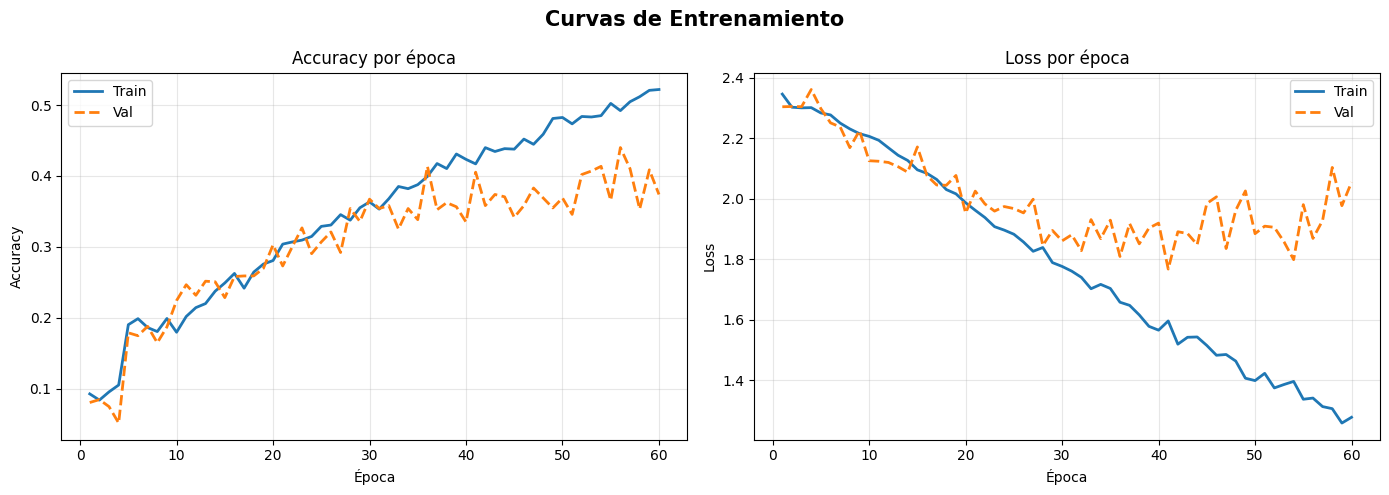

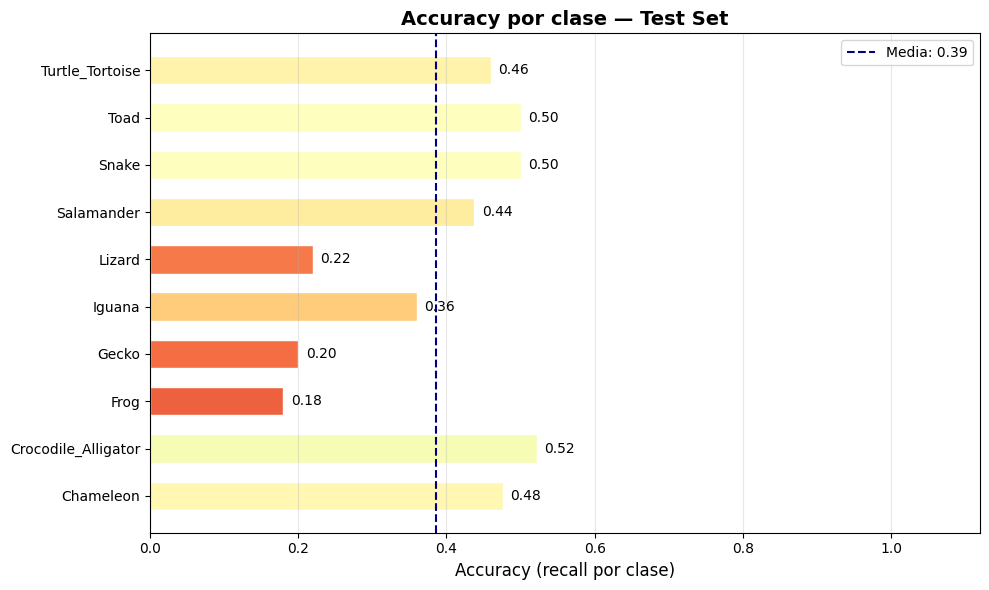

In [9]:
modelo.save('modelo_final.keras')
print("\n modelo_final.keras guardado")

 
test_generator.reset()
y_pred_probs = modelo.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes  
 
print(classification_report(y_true, y_pred, target_names=class_names))
 
# Accuracy por clase como dict para las gráficas
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
per_class_acc = [report[c]['recall'] for c in class_names] 
 

 
# Curvas de entrenamiento (Accuracy + Loss)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Curvas de Entrenamiento', fontsize=15, fontweight='bold')
 
epochs_ran = range(1, len(history.history['accuracy']) + 1)
 
axes[0].plot(epochs_ran, history.history['accuracy'],     label='Train', linewidth=2)
axes[0].plot(epochs_ran, history.history['val_accuracy'], label='Val',   linewidth=2, linestyle='--')
axes[0].set_title('Accuracy por época')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
 
axes[1].plot(epochs_ran, history.history['loss'],     label='Train', linewidth=2)
axes[1].plot(epochs_ran, history.history['val_loss'], label='Val',   linewidth=2, linestyle='--')
axes[1].set_title('Loss por época')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig('curvas_entrenamiento.png', dpi=150, bbox_inches='tight')
plt.show()
 
 
#Accuracy por clase (barra horizontal)
mean_acc = np.mean(per_class_acc)
colors = cm.RdYlGn([v for v in per_class_acc])
 
fig, ax = plt.subplots(figsize=(10, max(5, num_classes * 0.6)))
bars = ax.barh(class_names, per_class_acc, color=colors, edgecolor='white', height=0.6)
ax.axvline(mean_acc, color='navy', linestyle='--', linewidth=1.5,
           label=f'Media: {mean_acc:.2f}')
ax.set_xlim(0, 1.12)
ax.set_xlabel('Accuracy (recall por clase)', fontsize=12)
ax.set_title('Accuracy por clase — Test Set', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='x', alpha=0.3)
 
for bar, val in zip(bars, per_class_acc):
    ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', fontsize=10)
 
plt.tight_layout()
plt.savefig('accuracy_por_clase.png', dpi=150, bbox_inches='tight')
plt.show()